# FIt experimental data
Work on hi and si

In [2]:
import numpy as np
import torch
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt

In [ ]:
p_sil=(1-0.001)**200#0.75# 10-3 mutation rate times nb of amino acids=250 so total is 0.25 mutation per cycle
p_let=0.05*(1-p_sil)
p_aa=0.95*(1-p_sil)
mu_M=-0.13*np.log(10)
sigma_M=0.37*np.log(10)
S_mat=None                      # shape (N_h, n_A) : s_{k,v} ∈ {±1}

E_a=np.log(40)                        # Ag-gate threshold
kBT=1                       # thermal factor
N_i=1500  
N_max=1500 
mu_i=0.0 
sigma_i=0.05
p_diff=0.10


    # ---------------- mutation statistics -------------------------------
f_aa  = p_aa / (p_aa + p_sil)
f_sil = 1.0 - f_aa
v_adv = f_aa * mu_M
D     = f_aa * (sigma_M**2 + f_sil * mu_M**2)
lam = np.log(2.0) + np.log1p(-p_let) + np.log1p(-p_diff)

NameError: name 'np' is not defined

: 

In [ ]:


# ---------------------------------------------------------------------
# 1.  Run FP simulation  +  build Γ & ∇Γ lists
# ---------------------------------------------------------------------
def fp_density_time_series_kD(
    # biological / model parameters ---------------------------------------

    get_C=lambda t, v: 5.0,          # user-supplied concentration C_v(t)
    S_mat=np.array([[1.0]]),                      # shape (N_h, n_A) : s_{k,v} ∈ {±1}
    N_i=2500,  N_max=2500,
    # grid / time ----------------------------------------------------------
    h_min=-10.0, h_max=10.0, d_h=0.1,
    T=60.0,  dt=0.01,
    # output ---------------------------------------------------------------
    snapshot_interval=0.005,
    verbose=False,
):
    """
    Simulate k-dimensional GC Fokker–Planck dynamics in h-space.

    Parameters
    ----------
    S_mat : ndarray (N_h, n_A)
        Binary motif matrix: each column = antigen, each row = shape component.
    get_C : callable (t, v) → C_v(t)
        Returns surface concentration of antigen v at time t.
    """
    # ---------------- basic checks --------------------------------------
    if S_mat is None:
        raise ValueError("S_mat (binary motif matrix) must be provided")
    N_h, n_A = S_mat.shape          # k = dimension of h


    print('D=',D)

    if D > 0.0:
        dt_max = d_h**2 / (2.0 * N_h * D)
        if dt > dt_max:
            raise ValueError(f"dt = {dt:.3g} exceeds CFL limit {dt_max:.3g}")


    # ---------------- k-dim Cartesian grid ------------------------------
    h_axis = np.arange(h_min, h_max + d_h, d_h)
    h_axes = (h_axis,) * N_h
    h_mesh = np.meshgrid(*h_axes, indexing="ij")      # list of length k
    dH     = d_h**N_h

    # ---------------- Gaussian initial population -----------------------
    g1d = np.exp(-(h_axis - mu_i) ** 2 / (2.0 * sigma_i**2))
    rho = np.prod(np.meshgrid(*([g1d] * N_h), indexing="ij"), axis=0)
    rho *= N_i / (rho.sum() * dH)

    snapshots = [rho.copy()]
    times     = [0.0]

    # ---------------- pre-allocate helper arrays ------------------------
    E_stack = np.zeros((n_A,) + rho.shape)           # energies  E_v(h)

    n_steps    = int(round(T / dt))
    snap_every = max(1, int(round(snapshot_interval / dt)))
    omegas=[0]
    # -------------------------------------------------------------------
    for step in range(1, n_steps + 1):
        t_now = step * dt
        N_pop = rho.sum() * dH

        # --- time-dependent concentrations -----------------------------
        C_vec  = np.array([get_C(t_now, v) for v in range(n_A)], dtype=float)
        C_tot  = C_vec.sum()

        # If no antigen is present, skip selection (pure drift/diffusion)
        if C_tot == 0.0:
            if verbose and step % snap_every == 0:
                print(f"{step:5d}  t={t_now:6.2f}  (no antigen present)")
            if step % snap_every == 0:
                snapshots.append(rho.copy());  times.append(t_now)
            continue

        # --- binding energies  E_v(h) ----------------------------------
        # S_mat.T : (n_A, N_h);  stacked h_mesh : (N_h, …grid…)
        E_stack = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))
        #            → shape (n_A, …grid…)

        # Broadcast C_v to all grid points
        C_broad = C_vec.reshape((n_A,) + (1,) * N_h)

        # --- antigen internalisation gate  P_Ag ------------------------
        exp_term  = np.exp((E_stack - E_a) / kBT)
        numer_PAg = (C_broad * exp_term).sum(axis=0)
        P_Ag      = numer_PAg / (1.0 + numer_PAg)

        # --- T‐cell help gate  P_T  (concentration-weighted) ----------
        eE   = np.exp(E_stack / kBT)
        Phi  =  eE.sum(axis=0)                 # Σ_v  e^{E_v/kBT}
        Phi_bar = (rho * Phi).sum() * dH / N_pop
        P_T  = Phi / (Phi + Phi_bar / C_tot)

        # --- growth/decay rate Γ(h,t) ----------------------------------
        log_sel = np.log(P_Ag) + np.log(P_T)
        avg_log = (rho * log_sel).sum() * dH / N_pop
        #print avg of logPag and logPt
        # print(f"avg_logPag={(rho * np.log(P_Ag)).sum() * dH / N_pop:.3f}")
        # print(f"avg_logPt={(rho * np.log(P_T)).sum() * dH / N_pop:.3f}")
        Omega   = 0.0 if N_pop < N_max else max(0.0, lam + avg_log)
        Gamma   = lam + log_sel - Omega


        # --- conservative flux divergence ------------------------------
        div_total = np.zeros_like(rho)
        for ax in range(N_h):
            rho_fwd  = np.roll(rho, -1, axis=ax)

            adv_flux  = v_adv * (rho if v_adv >= 0 else rho_fwd)
            diff_flux = -0.5 * D * (rho_fwd - rho) / d_h
            J_int     = adv_flux + diff_flux            # at cell interfaces

            # trim last cell (fwd neighbour outside domain)
            slc = [slice(None)] * N_h;  slc[ax] = slice(0, -1)
            J_int = J_int[tuple(slc)]

            # build full flux array with zero at boundaries
            J_shape = list(rho.shape); J_shape[ax] += 1
            J = np.zeros(J_shape)
            idx = [slice(None)] * N_h;  idx[ax] = slice(1, -1)
            J[tuple(idx)] = J_int

            div_total += np.diff(J, axis=ax) / d_h

        # --- explicit Euler update -------------------------------------
        rho += dt * (Gamma * rho - div_total)
        np.maximum(rho, 0.0, out=rho)                    # clip negatives

        # --- book-keeping ----------------------------------------------
        if step % snap_every == 0:
            snapshots.append(rho.copy())
            times.append(t_now)
            omegas.append(Omega)

        if verbose and step % snap_every == 0:
            mean_Gamma = (rho * Gamma).sum() * dH / N_pop
            mean_h = [(rho * h_mesh[ax]).sum() * dH / N_pop for ax in range(N_h)]
            mean_h_str = "  ".join(f"⟨h_{i+1}⟩={m:6.2f}" for i, m in enumerate(mean_h))
            print(f"{step:5d}  t={t_now:6.2f}  N={N_pop:8.1f}  Ω={Omega:7.3f}  "
                  f"⟨Γ⟩={mean_Gamma:8.3f}  {mean_h_str}")

    return h_axes, np.array(times), np.stack(snapshots), np.array(omegas)



# Test C

D= 0.19093366060479736
D= 0.19093366060479736
D= 0.19093366060479736


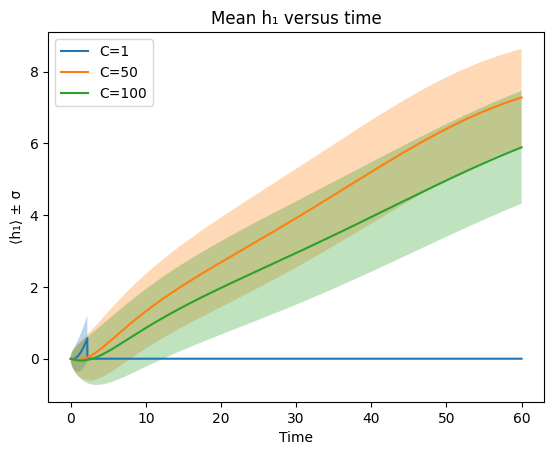

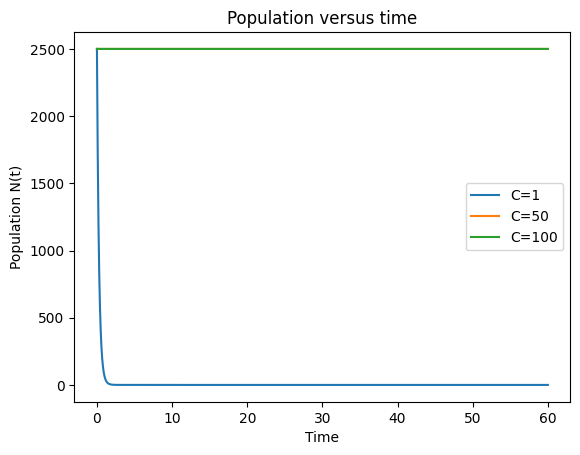

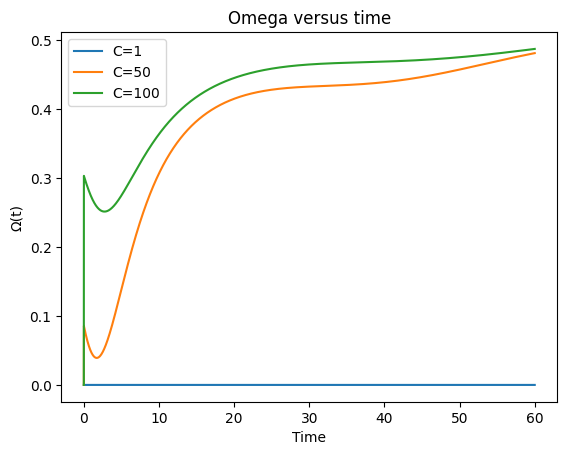

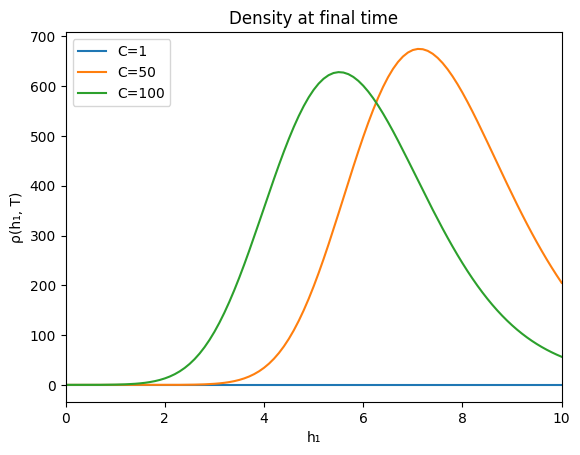

In [ ]:
# ---------------------------------------------------------------------
# 2.  Run simulations for C = 1, 10, 100
# ---------------------------------------------------------------------
C_vals = [1, 50, 100]
results = {}

for C0 in C_vals:
    get_C = lambda t, v, C0=C0: C0
    h_axes, t, snaps, omegas = fp_density_time_series_kD(
        get_C=get_C,T=60
        # keep all other params default (feel free to tweak)
    )
    h_axis = h_axes[0]
    d_h = h_axis[1] - h_axis[0]
    dH = d_h  # N_h = 1 → volume element

    mean_h, std_h, pops = [], [], []
    for rho in snaps:
        N_pop = rho.sum() * dH
        pops.append(N_pop)
        m1 = (rho * h_axis).sum() * dH / N_pop
        m2 = (rho * h_axis**2).sum() * dH / N_pop
        #if no pop, skip std calculation
        if N_pop <1:
            std_h.append(0.0)
            mean_h.append(0.0)
            continue
        mean_h.append(m1)
        std_h.append(np.sqrt(max(0.0, m2 - m1**2)))

    results[C0] = {
        "t": t,
        "mean_h": np.array(mean_h),
        "std_h":  np.array(std_h),
        "pop":    np.array(pops),
        "omega":  omegas,
        "h_axis": h_axis,
        "rho_final": snaps[-1],
    }

# ---------------------------------------------------------------------
# 3.  Create the requested plots (4 separate figures, no custom colors)
# ---------------------------------------------------------------------

# 3.1 Mean h1 ± std
plt.figure()
for C0 in C_vals:
    res = results[C0]
    line, = plt.plot(res["t"], res["mean_h"], label=f"C={C0}")
    plt.fill_between(res["t"],
                     res["mean_h"] - res["std_h"],
                     res["mean_h"] + res["std_h"],
                     alpha=0.3)
plt.xlabel("Time")
plt.ylabel("⟨h₁⟩ ± σ")
plt.title("Mean h₁ versus time")
plt.legend()

# 3.2 Population size
plt.figure()
for C0 in C_vals:
    res = results[C0]
    plt.plot(res["t"], res["pop"], label=f"C={C0}")
plt.xlabel("Time")
plt.ylabel("Population N(t)")
plt.title("Population versus time")
plt.legend()

# 3.3 Ω(t)
plt.figure()
for C0 in C_vals:
    res = results[C0]
    plt.plot(res["t"], res["omega"], label=f"C={C0}")
plt.xlabel("Time")
plt.ylabel("Ω(t)")
plt.title("Omega versus time")
plt.legend()

# 3.4 Final density ρ(h₁, T)
plt.figure()
for C0 in C_vals:
    res = results[C0]
    plt.plot(res["h_axis"], res["rho_final"], label=f"C={C0}")
plt.xlabel("h₁")
plt.ylabel("ρ(h₁, T)")
plt.title("Density at final time")
#x lim entre 0 et 10
plt.xlim(0, 10)
plt.legend()

plt.show()

# Comparison to experimental data

In [ ]:
# ==============================================================
# 0.  Imports & experimental data
# ==============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -- load experiment -------------------------------------------
df = (pd.read_csv("data_mat/data.csv", keep_default_na=False)
        [["time (days)", "delta_bind_CGG"]]
        .rename(columns={"time (days)": "t", "delta_bind_CGG": "x"}))

df["t"] = df["t"] * 2.0            # days  →  12 h
df["x"] = df["x"] * np.log(10.0)   # log scale

times_exp = np.sort(df.t.unique())
mean_exp  = (df.groupby("t")["x"]
               .mean()
               .reindex(times_exp)
               .values)

print("mean_exp", mean_exp)
print("times_exp", times_exp)  # in 12 h

# ==============================================================
# 1.  FP wrapper → mean ⟨h1⟩ at experimental times
# ==============================================================
def simulate_means(
        C,
   ):
    """
    Run the FP solver (single antigen, S_mat=[[1.0]]) and return simulated
    ⟨h1⟩ values **interpolated onto `times_exp`**.
    """
 

    # ----- run FP ---------------------------------------------------

    h_axes, times_sim, snaps, omegas = fp_density_time_series_kD(
        get_C=lambda t, v: C,T=141
        # keep all other params default (feel free to tweak)
    )

    h_axis = h_axes[0]
    mean_sim = np.array([(r * h_axis).sum() / r.sum() for r in snaps])

    # Interpolate onto the experimental time grid
    mean_interp = np.interp(times_exp, times_sim, mean_sim)
    return mean_interp

# ==============================================================
# 2.  Loss function (MSE on identical time grid)
# ==============================================================
def mse_loss(C):
    if not (0.1 <= C <= 50.0):
        return 1e9                     # out‑of‑bounds penalty
    pred = simulate_means(C)
    return np.mean((pred - mean_exp) ** 2)

# ==============================================================
# 3.  Grid Search over C values (log scale)
# ==============================================================
# log_C_values = np.logspace(-1, 3, 10)  # 0.1 → 1000

# results = []
# for C in log_C_values:
#     loss = mse_loss(C)
#     results.append((C, loss))

# # Best C
# best_C, best_loss = min(results, key=lambda x: x[1])
# print(f"Best C = {best_C:.4f},  MSE = {best_loss:.6f}")


mean_exp [-0.12944443 -0.37343535  0.50442515  1.31840739  2.11250799  2.29889219
  6.60429562]
times_exp [ 10.  16.  22.  28.  34.  40. 140.]


In [ ]:
def simulate_means_total(C, 
                  ):
    """
    Run the FP solver (one antigen, S_mat=[[1.0]]) and return ⟨h1⟩
    interpolated on `times_exp`.  CFL stability is enforced automatically.
    """


    # ----- run FP ---------------------------------------------------
    h_axes, times_sim, snaps, omegas = fp_density_time_series_kD(
        get_C=lambda t, v: C,T=141
        # keep all other params default (feel free to tweak)
    )

        

    h_axis = h_axes[0]
    mean_sim = np.array([(r * h_axis).sum() / r.sum() for r in snaps])
    std_sim = np.array([(r * (h_axis - m) ** 2).sum() / r.sum() for r, m in zip(snaps, mean_sim)])
    return times_sim, mean_sim, std_sim

#plot


D= 0.19093366060479736


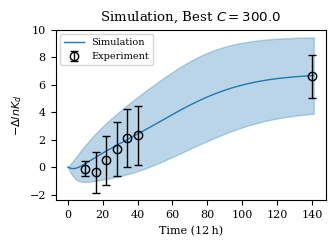

In [ ]:
# ──────────────────────────────────────────────────────────────
# stats for the experimental curve
exp_mean  = mean_exp
exp_std   = (df.groupby("t")["x"].std()
               .reindex(times_exp)
               .fillna(0.0)          # if only one replica at a time point
               .values)

# ──────────────────────────────────────────────────────────────
best_C=300
times_sim, mean_sim, std_sim = simulate_means_total(best_C)

plt.rcParams.update({                 # PRL‑like defaults
    "font.family": "serif",
    "font.size":   8,
    "figure.figsize": (3.4, 2.5),    # single‑column
    "lines.linewidth": 1,
})
plt.figure(dpi=100)

# simulation: blue solid line with shaded ±1σ band
plt.plot(times_sim, mean_sim, color='C0', label='Simulation')
plt.fill_between(times_sim, mean_sim - std_sim, mean_sim + std_sim,
                 color='C0', alpha=0.3)


# experiment: black open circles with error bars (if non‑zero)
plt.errorbar(times_exp, exp_mean, yerr=exp_std,
             fmt='o', mfc='none', ecolor='k', color='k',
             capsize=3, label='Experiment')

plt.xlabel('Time (12 h)')
plt.ylabel(r'$-\Delta ln K_d$')
plt.title(f'Simulation, Best $C = {best_C:.1f}$')
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()